# Linear Regression (Supervised Learning)

## Step 1: Retrieve data- Using the Boston Dataset

In [1]:
#import pandas as pd

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#file_path = '/content/sample_data/HousingData.csv'

# Read the CSV file
#dataset = pd.read_csv(file_path)

# URL to the online dataset
url = 'https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv'

# Read the CSV file from the URL
dataset = pd.read_csv(url)




## Step 2: Data understanding

In [3]:
print("Features (Columns):")
print(dataset.columns)



Features (Columns):
Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')


In [ ]:
print(dataset.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None


In [ ]:

# Print all values in the dataset
print(dataset.values)


[[6.3200e-03 1.8000e+01 2.3100e+00 ... 3.9690e+02 4.9800e+00 2.4000e+01]
 [2.7310e-02 0.0000e+00 7.0700e+00 ... 3.9690e+02 9.1400e+00 2.1600e+01]
 [2.7290e-02 0.0000e+00 7.0700e+00 ... 3.9283e+02 4.0300e+00 3.4700e+01]
 ...
 [6.0760e-02 0.0000e+00 1.1930e+01 ... 3.9690e+02 5.6400e+00 2.3900e+01]
 [1.0959e-01 0.0000e+00 1.1930e+01 ... 3.9345e+02 6.4800e+00 2.2000e+01]
 [4.7410e-02 0.0000e+00 1.1930e+01 ... 3.9690e+02 7.8800e+00 1.1900e+01]]


In [4]:
# Assuming 'medv' is the column you want to print
column_to_print = 'medv'

# Print the specified column
print(dataset[column_to_print])


0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: medv, Length: 506, dtype: float64


## Feature Selection

In [ ]:
#There are 13 features in the dataset
#we want to choose those features that directly influence the result (that is, prices of houses) to train the model.
#From the MEDV column in the output, can see that the RM and LSTAT features have high correlation factors (positive and negative correlations) with the MEDV

#LSTAT	-0.737663
#as LSTAT (“% of lower status of the population”) increases, the prices of houses go down.
#When LSTAT decreases, the prices go up.

#RM	0.695360
#as RM (“average number of rooms per dwelling”) increases, so will the price.
#And when RM goes down, the prices go down as well.

corr = dataset.corr()
print(corr)


             crim        zn     indus      chas       nox        rm       age  \
crim     1.000000 -0.200469  0.406583 -0.055892  0.420972 -0.219247  0.352734   
zn      -0.200469  1.000000 -0.533828 -0.042697 -0.516604  0.311991 -0.569537   
indus    0.406583 -0.533828  1.000000  0.062938  0.763651 -0.391676  0.644779   
chas    -0.055892 -0.042697  0.062938  1.000000  0.091203  0.091251  0.086518   
nox      0.420972 -0.516604  0.763651  0.091203  1.000000 -0.302188  0.731470   
rm      -0.219247  0.311991 -0.391676  0.091251 -0.302188  1.000000 -0.240265   
age      0.352734 -0.569537  0.644779  0.086518  0.731470 -0.240265  1.000000   
dis     -0.379670  0.664408 -0.708027 -0.099176 -0.769230  0.205246 -0.747881   
rad      0.625505 -0.311948  0.595129 -0.007368  0.611441 -0.209847  0.456022   
tax      0.582764 -0.314563  0.720760 -0.035587  0.668023 -0.292048  0.506456   
ptratio  0.289946 -0.391679  0.383248 -0.121515  0.188933 -0.355501  0.261515   
b       -0.385064  0.175520 

Correlation analysis

In [ ]:
#---get the top 3 features that has the highest correlation---
print(dataset.corr().abs().nlargest(3, 'medv').index)

#---print the top 3 correlation values---
print(dataset.corr().abs().nlargest(3, 'medv').values[:,13])


Index(['medv', 'lstat', 'rm'], dtype='object')
[1.         0.73766273 0.69535995]


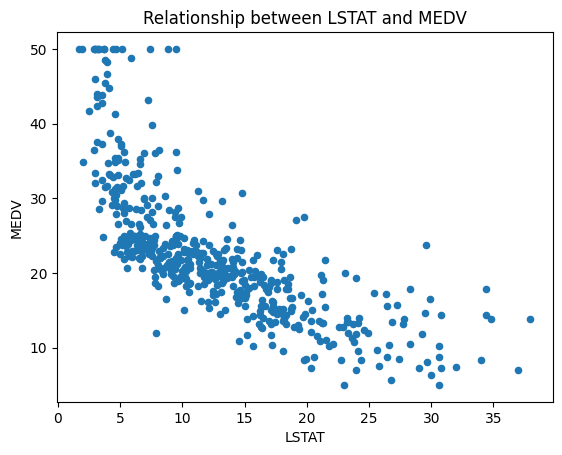

In [ ]:
plt.scatter(dataset['lstat'], dataset['medv'], s=20, marker='o')
plt.xlabel('LSTAT')
plt.ylabel('MEDV')
plt.title('Relationship between LSTAT and MEDV')
plt.show()  # <--- this line forces the chart to appear




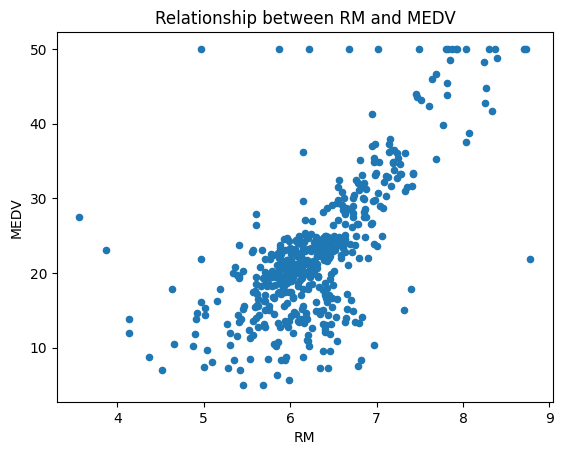

In [5]:
plt.scatter(dataset['rm'], dataset['medv'], s=20, marker='o')
plt.xlabel('RM')       # average number of rooms per dwelling
plt.ylabel('MEDV')     # median value of owner-occupied homes
plt.title('Relationship between RM and MEDV')
plt.show()


## Step 3: Data Cleansing/ Data pre-processing


In [6]:
#to check the data type of each field
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
#to check to see if there are any missing values
# the below dataset is good, as it does not have any missing values:

print(dataset.isnull().sum())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


## Step 4: Apply the model---> Linear Regression

In [7]:
#First, create two DataFrames: x and Y. The x DataFrame will contain the combination of the LSTAT and RM features,
#while the Y DataFrame will contain the MEDV label

x = pd.DataFrame(np.c_[dataset['lstat'], dataset['rm']], columns = ['lstat','rm'])
Y = dataset['medv']


# Step 5: Split datasets

In [8]:
#split the dataset into 70 percent for training and 30 percent for testing

from sklearn.model_selection import train_test_split
x_train, x_test, Y_train, Y_test = train_test_split(x, Y, test_size = 0.3,
                                                    random_state=5)


In [ ]:
#the testing set has 152 rows
print(x_test.shape)
print(Y_test.shape)


(152, 2)
(152,)


In [ ]:
#After the split, let’s print out the shape of the training sets:
#the x training set now has 354 rows and 2 columns (LSTAT + RM),
#while the Y training set (which contains the label) has 354 rows and 1 column.

#training (70%) = 354 rows, testing (30%) = 152 rows, total = 506

print(x_train.shape)
print(Y_train.shape)


(354, 2)
(354,)


# Step 6: Train model

In [9]:
#train model

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, Y_train)


LinearRegression()

## Step 7: Do prediction

In [10]:
#we will use the testing set to perform some predictions:

price_pred = model.predict(x_test)
print (price_pred)


[37.1689804  29.32035435 25.58027087  1.15646598 33.20707082  8.44197544
 30.37221305 27.57463198 26.12976704 22.01624296 32.13551356 22.87944818
 22.66492916 30.77766892 26.87728603 20.52649771  0.07700859 17.73715803
 12.4852138  21.5337132   5.41730621 23.83920281 37.59483142 24.38880315
 29.45572317 12.97936433 26.66174451 22.28532221 27.15672582 28.55285561
 11.92050914 10.73457063 18.04609262 25.06581211 26.04950614 22.86501105
 26.1328205  12.78655949 37.06519613 33.01820965 20.30298129  1.93992794
 27.34958946 16.72165643 27.15469487 29.58123631 -2.17117984 17.36152288
 20.6656613  14.2815521  20.69641698 21.34126367 24.86153667 16.4242525
 17.55536557 27.42110603 35.81573065 19.9548413  28.51674903 20.32610396
 20.05492026 22.80452284 16.55464235 30.90531655 22.41792004 13.19072701
 23.32544191 25.48850806 22.6711396  21.3650088  19.39396145 26.0214486
 16.76791647 20.44659086 19.48139777 29.92580392 19.25450197 13.28096308
 28.36799435 19.04982456 21.99396576 38.66237215 16.0

Enter lstat value: 5
Enter rm value: 7
Predicted price: 30.91031148480356

Enter lstat value: 25
Enter rm value: 5
Predicted price: 8.054765530847323

In [11]:

# Get user input for LSTAT and RM features
user_input_lstat = float(input("Enter lstat value: "))
user_input_rm = float(input("Enter rm value: "))

# Create a DataFrame for user input
user_input_df = pd.DataFrame({'lstat': [user_input_lstat], 'rm': [user_input_rm]})

# Perform prediction for user input
price_pred = model.predict(user_input_df)

# Display predicted output
print("Predicted price:", price_pred[0])


Enter lstat value: 5
Enter rm value: 20
Predicted price: 93.72599706765143


# Step 8: Evaluate the model performance

In [14]:
#To learn how well our model performed, we use the R-Squared method
#aim for a value of R-Squared that is close to 1:

print('R-squared: %.4f' % model.score(x_test,
                                      Y_test))


R-squared: 0.6162


In [ ]:
#from sklearn.metrics import mean_squared_error
#mse = mean_squared_error(Y_test, price_pred)
#print(mse)
#plt.scatter(Y_test, price_pred)
#plt.xlabel("Actual Prices")
#plt.ylabel("Predicted prices")
#plt.title("Actual prices vs Predicted prices")




## Step 9: Save model

In [13]:
import joblib
joblib.dump(model, 'linear_regression_model.pkl')

['linear_regression_model.pkl']

In [ ]:
# ===================== REUSE AND PREDICT WITH TRAINED MODEL =====================

import numpy as np
import pandas as pd
import joblib

# 1️⃣ Reuse existing trained model (or load from file if needed)
try:
    estimator = model  # change if your variable name is lin_reg, reg, etc.
    print("Using model from current notebook session.")
except NameError:
    estimator = joblib.load("linear_regression_model.joblib")
    print("Loaded model from file: linear_regression_model.joblib")

# 2️⃣ Test prediction using existing test data
try:
    y_pred = estimator.predict(X_test)
    print("\nPrediction on test data (first 5 samples):")
    print("Predicted:", np.round(y_pred[:5], 3))
    print("Actual   :", np.round(y_test[:5], 3))
except Exception as e:
    print("Cannot predict on X_test:", e)

# 3️⃣ Predict a new sample manually
#    👉 Option A: If your model was trained on a DataFrame with named columns
try:
    if hasattr(X_test, "columns"):
        feature_names = list(X_test.columns)
        print("\nFeature names:", feature_names)
        # Example: fill in your own values below
        new_data = pd.DataFrame([{
            feature_names[0]: 3.5,
            feature_names[1]: 2.1,
            # add more features if needed
        }])
        new_pred = estimator.predict(new_data)
        print("\nPrediction for new sample (dict-based):", new_pred)
    else:
        # Option B: For numpy array style training
        new_sample = np.array([[3.5, 2.1]])  # replace with your feature values
        new_pred = estimator.predict(new_sample)
        print("\nPrediction for new sample (list-based):", new_pred)
except Exception as e:
    print("Error making new prediction:", e)

# 4️⃣ (Optional) Save model again if retrained
try:
    joblib.dump(estimator, "linear_regression_model.joblib")
    print("\nModel saved to linear_regression_model.joblib ✅")
except Exception as e:
    print("Model not saved:", e)


Using model from current notebook session.
Cannot predict on X_test: name 'X_test' is not defined
Error making new prediction: name 'X_test' is not defined

Model saved to linear_regression_model.joblib ✅
